In [1]:
import osmnx as ox
import geopandas as gpd 
import pandas as pd 


In [2]:
all_kunta = gpd.read_file('data/kunta_layer_finland.gpkg')

all_kunta.head()

,name,id,kunta,vuosi,nimi,namn,geometry
0,Alavieska,2,009,2026,Alavieska,Alavieska,"POLYGON ((382543.364 7120022.976, 372645.944 7..."
1,Enontekiö,11,047,2026,Enontekiö,Enontekis,"POLYGON ((414458.47 7606155.54, 418947.929 758..."
2,Evijärvi,15,052,2026,Evijärvi,Evijärvi,"POLYGON ((334929.075 7032219.92, 334844.877 70..."
3,Haapajärvi,20,069,2026,Haapajärvi,Haapajärvi,"POLYGON ((419904.813 7090244.14, 428100.788 70..."
4,Haapavesi,21,071,2026,Haapavesi,Haapavesi,"POLYGON ((440434.527 7109915.434, 434209.923 7..."


## Rovaniemi

In [3]:
rovaniemi = all_kunta.loc[all_kunta['name']=='Rovaniemi'].reset_index(drop=True)

In [4]:
rovaniemi_wgs = rovaniemi.to_crs(4326)

In [5]:
rovaniemi_wgs.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

(395568.90385, 517266.63715, 7332222.368899999, 7458454.323100001)

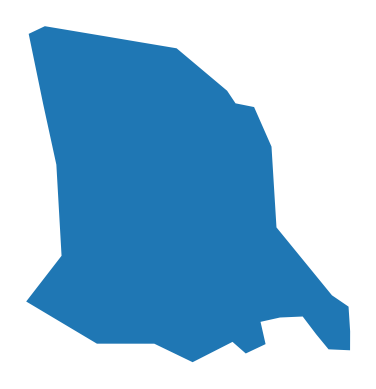

In [6]:
ax = rovaniemi.plot()

ax.axis('off')

In [46]:
rovaniemi.to_file('output/rovaniemi_kunta.geojson')

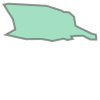

In [8]:
geom = rovaniemi_wgs.at[0, 'geometry']
geom

## Roads

In [9]:
# Get roads (retrieves walkable roads by default)
G = ox.graph_from_polygon(geom, network_type ='drive')

In [10]:
# Parse roads from the graph
roads = ox.graph_to_gdfs(G, nodes=False, edges=True) 

In [26]:
road_network = roads.reset_index(drop=True)

road_network = road_network[['geometry']]

In [27]:
road_network.head()

,geometry
0,"LINESTRING (25.73047 66.49717, 25.73029 66.49711)"
1,"LINESTRING (25.73047 66.49717, 25.73023 66.497..."
2,"LINESTRING (25.73001 66.49874, 25.72823 66.49885)"
3,"LINESTRING (25.73001 66.49874, 25.72886 66.497..."
4,"LINESTRING (25.73001 66.49874, 25.73203 66.498..."


(24.77747669, 27.36073451, 66.14885466, 67.21937774)

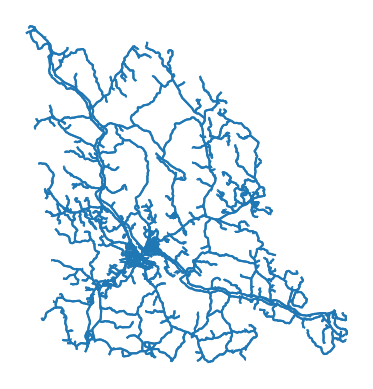

In [28]:
ax= road_network.plot()

ax.axis('off')

In [29]:
road_network.to_parquet('output/road_network_rovaniemi.parquet')

## Buildings

In [23]:
buildings = ox.features_from_polygon(geom, tags={"building": True})

In [24]:
buildings.head()

geometry  \
element  id                                                              
node     6647620582                          POINT (25.80296 66.49361)   
         7729116098                           POINT (25.84412 66.5327)   
         7813582048                          POINT (24.95567 67.16258)   
relation 2714915     POLYGON ((25.70373 66.50498, 25.7037 66.50496,...   
         15592357    POLYGON ((25.46404 66.42665, 25.46549 66.4266,...   

                       building building:levels height  \
element  id                                              
node     6647620582         yes               1      3   
         7729116098         yes             NaN    NaN   
         7813582048        shed             NaN    NaN   
relation 2714915            yes             NaN    NaN   
         15592357    commercial             NaN    NaN   

                                                 name addr:city  \
element  id                                                       
node     6647620582                           Puuvaja       NaN   
         7729116098                               NaN       NaN   
         7813582048                               NaN       NaN   
relation 2714915     Jokkakallion asumispalvelukeskus       NaN   
         15592357                                 NaN       NaN   

                    addr:housenumber addr:postcode addr:street alt_name  ...  \
element  id                                                              ...   
node     6647620582              NaN           NaN         NaN      NaN  ...   
         7729116098              NaN           NaN         NaN      NaN  ...   
         7813582048              NaN           NaN         NaN      NaN  ...   
relation 2714915                 NaN           NaN         NaN      NaN  ...   
         15592357                NaN           NaN         NaN      NaN  ...   

                    telecom pets addr:hamlet toilets:handwashing  \
element  id                                                        
node     6647620582     NaN  NaN         NaN                 NaN   
         7729116098     NaN  NaN         NaN                 NaN   
         7813582048     NaN  NaN         NaN                 NaN   
relation 2714915        NaN  NaN         NaN                 NaN   
         15592357       NaN  NaN         NaN                 NaN   

                    toilets:position end_date phone:mobile was:building  \
element  id                                                               
node     6647620582              NaN      NaN          NaN          NaN   
         7729116098              NaN      NaN          NaN          NaN   
         7813582048              NaN      NaN          NaN          NaN   
relation 2714915                 NaN      NaN          NaN          NaN   
         15592357                NaN      NaN          NaN          NaN   

                    animal_boarding          type  
element  id                                        
node     6647620582             NaN           NaN  
         7729116098             NaN           NaN  
         7813582048             NaN           NaN  
relation 2714915                NaN  multipolygon  
         15592357               NaN  multipolygon  

[5 rows x 171 columns]

In [32]:
buildings_coor = buildings.reset_index(drop=False)

buildings_coor = buildings_coor[[ 'id', 'geometry']]

buildings_coor['geometry'] = buildings_coor['geometry'].centroid

buildings_coor['longitude'] = [value.x for value in buildings_coor['geometry'] ]
buildings_coor['latitude'] = [value.y for value in buildings_coor['geometry'] ]

buildings_coor.head()

/run/nvme/job_32784318/tmp/ipykernel_1756857/993484618.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings_coor['geometry'] = buildings_coor['geometry'].centroid


,id,geometry,longitude,latitude
0,6647620582,POINT (25.80296 66.49361),25.802957,66.493611
1,7729116098,POINT (25.84412 66.5327),25.844125,66.532697
2,7813582048,POINT (24.95567 67.16258),24.955666,67.162578
3,2714915,POINT (25.70354 66.50513),25.703535,66.505131
4,15592357,POINT (25.46482 66.42647),25.464823,66.426465


(24.640690050000003, 27.37357845, 66.14756088746665, 67.22517902172561)

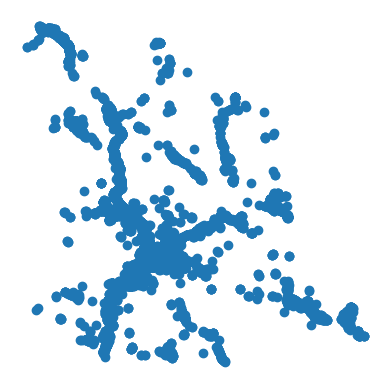

In [ ]:
ax= buildings_coor.plot()
-
ax.axis('off')

In [34]:
len(buildings_coor)

18045

In [36]:
buildings_view = buildings_coor[['longitude', 'latitude']]

buildings_view

,longitude,latitude
0,25.802957,66.493611
1,25.844125,66.532697
2,24.955666,67.162578
3,25.703535,66.505131
4,25.464823,66.426465
...,...,...
18040,25.720774,66.505777
18041,25.719336,66.506956
18042,25.716955,66.505092
18043,25.718769,66.504141


In [37]:
type(buildings_view)

pandas.core.frame.DataFrame

In [38]:
buildings_view.to_csv('output/buildings_rovaniemi.csv', index=False)

## EV Infraestructure

In [39]:
ev_charging = ox.features_from_polygon(geom, tags={"amenity": 'charging_station'})

In [41]:
ev_charging_coor = ev_charging.reset_index(drop=False)

ev_charging_coor = ev_charging_coor[[ 'id', 'geometry']]

ev_charging_coor['geometry'] = ev_charging_coor['geometry'].centroid

ev_charging_coor['longitude'] = [value.x for value in ev_charging_coor['geometry'] ]
ev_charging_coor['latitude'] = [value.y for value in ev_charging_coor['geometry'] ]

/run/nvme/job_32784318/tmp/ipykernel_1756857/4264936483.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ev_charging_coor['geometry'] = ev_charging_coor['geometry'].centroid


(24.911055115, 25.901923785, 66.32794992, 67.20722788)

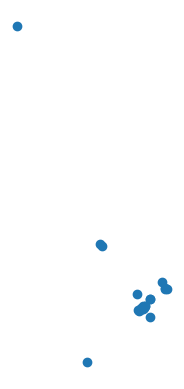

In [42]:
ax= ev_charging_coor.plot()

ax.axis('off')

In [44]:
ev_charging_view = ev_charging_coor[['longitude', 'latitude']]

ev_charging_view

,longitude,latitude
0,25.722570,66.501980
1,25.686167,66.489892
2,24.956095,67.167261
3,25.754472,66.518917
4,25.702718,66.496449
5,25.466046,66.644117
6,25.455338,66.649252
7,25.828467,66.557914
8,25.757004,66.517640
9,25.685238,66.492290


In [45]:
ev_charging_view.to_csv('output/ev_charging_rovaniemi.csv', index=False)

## Transform

In [11]:
buildings_rov_pq = pd.read_csv('output/buildings_rovaniemi.csv')

In [12]:
import geopandas as gpd

# Create GeoDataFrame from longitude and latitude
buildings_rova_geopq = gpd.GeoDataFrame(
    buildings_rov_pq,
    geometry=gpd.points_from_xy(
        buildings_rov_pq["longitude"],
        buildings_rov_pq["latitude"]
    ),
    crs="EPSG:4326"  # WGS84 coordinate system
)

# Optional: preview
buildings_rova_geopq.head()

,longitude,latitude,geometry
0,25.802957,66.493611,POINT (25.80296 66.49361)
1,25.844125,66.532697,POINT (25.84412 66.5327)
2,24.955666,67.162578,POINT (24.95567 67.16258)
3,25.703535,66.505131,POINT (25.70354 66.50513)
4,25.464823,66.426465,POINT (25.46482 66.42647)


In [13]:
buildings_rova_geopq.to_parquet('output/buildings_rovaniemi.parquet')